In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving Pizza-3007395.jpg to Pizza-3007395 (1).jpg


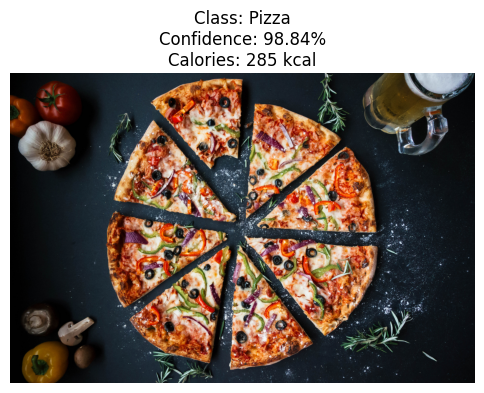

Top 3 Predictions:
- Pizza: 98.84%
- Apple Pie: 0.73%
- Cheesecake: 0.23%


In [35]:
from fastai.vision.all import *
from google.colab import files
import matplotlib.pyplot as plt

learn = load_learner('/content/drive/MyDrive/food11_model.pkl')

calorie_map = {
    "apple_pie": 320,
    "cheesecake": 350,
    "chicken_curry": 250,
    "french_fries": 312,
    "fried_rice": 330,
    "hamburger": 295,
    "hot_dog": 290,
    "ice_cream": 207,
    "omelette": 154,
    "pizza": 285,
    "sushi": 200
}

uploaded = files.upload()

for file_name in uploaded.keys():
    img = PILImage.create(file_name)
    pred, pred_idx, probs = learn.predict(img)

    food = str(pred)
    pretty_food = food.replace("_", " ").title()
    confidence = float(probs[pred_idx]) * 100
    calories = calorie_map.get(food, "Unknown")

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Class: {pretty_food}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Calories: {calories} kcal"
    )
    plt.show()

    print("Top 3 Predictions:")
    top3_idx = probs.argsort(descending=True)[:3]
    for i in top3_idx:
        label = learn.dls.vocab[int(i)]
        label_pretty = str(label).replace("_", " ").title()
        score = float(probs[int(i)]) * 100
        print(f"- {label_pretty}: {score:.2f}%")